<a href="https://colab.research.google.com/github/bruly694/AI-TRAINNINGs/blob/kibu/CancerLogistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

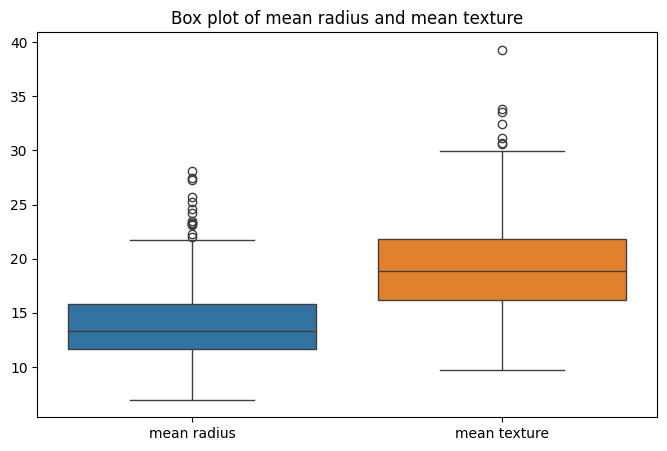

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
#load an existing dataset
from sklearn.datasets import load_breast_cancer
data =load_breast_cancer()
df=pd.DataFrame(data.data,columns=data.feature_names)
df['malignant']=data.target
#exploratory data analysis(EDA)
print(df.info())
print(df.describe())
#box plot(using only two key featurs)
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['mean radius','mean texture']])
plt.title('Box plot of mean radius and mean texture')
plt.show()


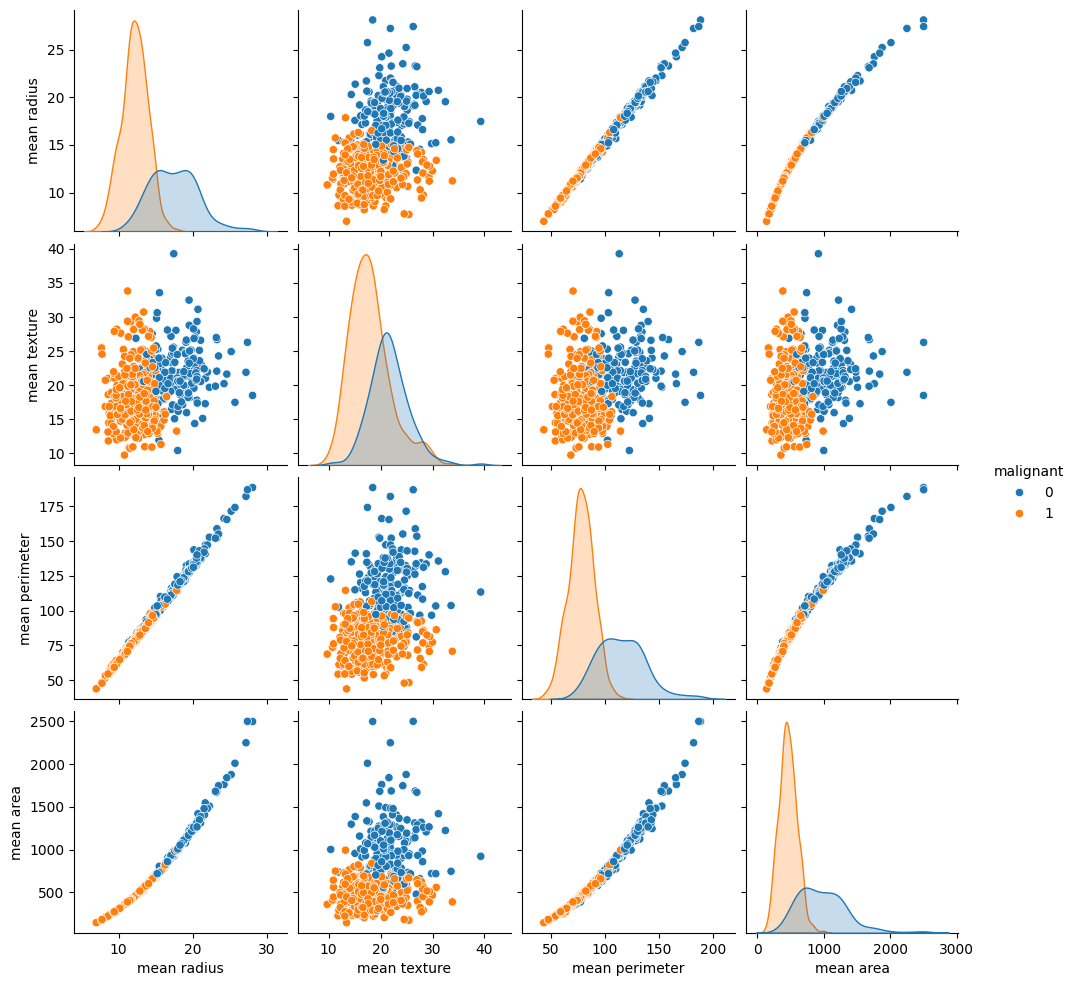

In [ ]:
#pair plot
sns.pairplot(df[['mean radius','mean texture','mean perimeter','mean area','malignant']], hue='malignant')
plt.show()

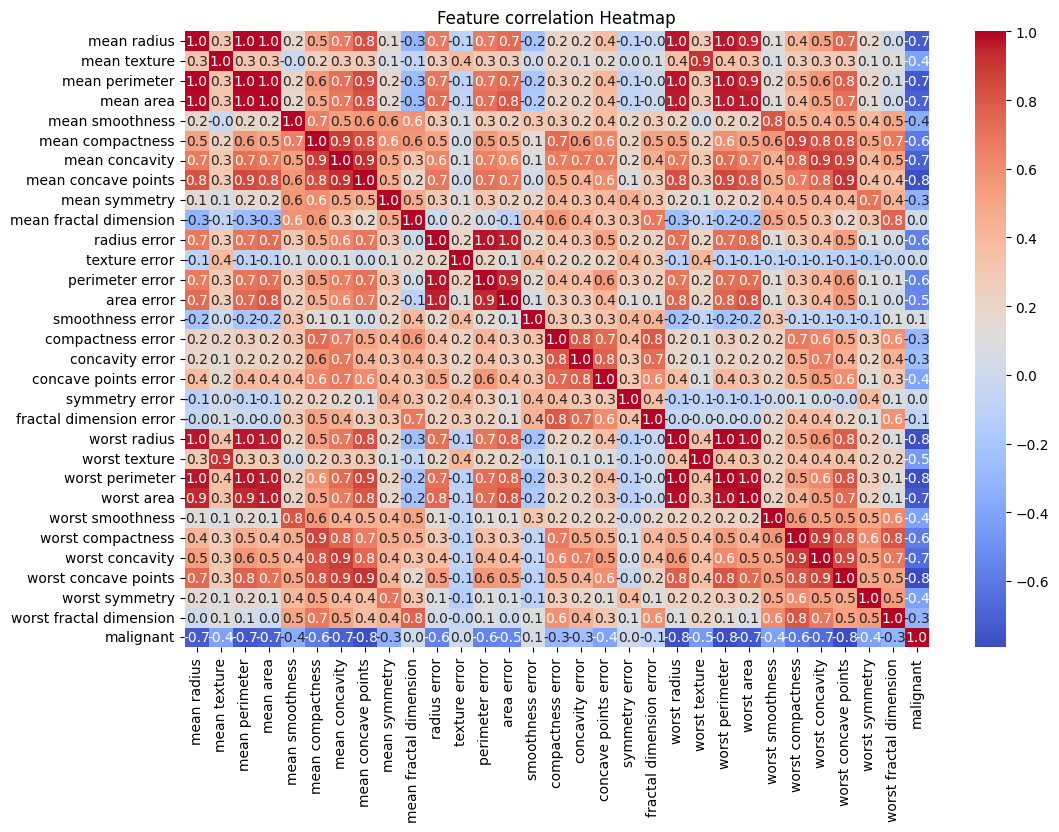

In [ ]:
#heatmap of feature correlations
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.1f')
plt.title("Feature correlation Heatmap")
plt.show()



In [ ]:
#data scaling and normalizati
scaler=StandardScaler()
df[data.feature_names]=scaler.fit_transform(df[data.feature_names])

In [ ]:
#split dataset
X=df[data.feature_names]
Y=df['malignant']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)


In [ ]:
#Model training

model=LogisticRegression()
model.fit(X_train,Y_train)

NameError: name 'X_train' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#Model Evaluat
predictions = model.predict(X_test)
print("Accuracy:",accuracy_score(Y_test,predictions))
print("Classification Report:\n",classification_report(Y_test,predictions))

Accuracy: 0.956140350877193
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



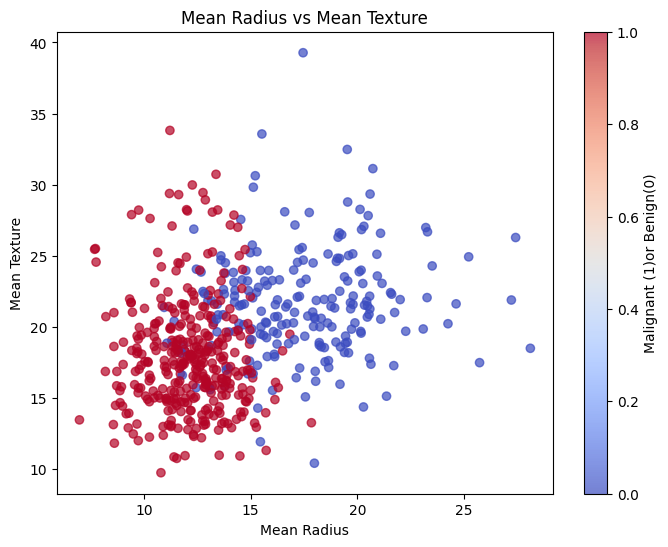

In [ ]:
#visualizatio using matplotlib scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df['mean radius'],df['mean texture'],c=df['malignant'],cmap='coolwarm',alpha=0.7)
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.title('Mean Radius vs Mean Texture')
plt.colorbar(label='Malignant (1)or Benign(0)')

plt.show()

In [ ]:
#user input for prediction
print("Enter feature value for prediction:")
user_input=[]
for feature in data.feature_names:
    value=float(input(f"{feature}:"))
    user_input.append(value)
scaled_input=scaler.transform([user_input])
result=model.predict(scaled_input)[0]
print(f'predicted:{"malignant" if result==1 else "Benign"}')



Enter feature value for prediction:


KeyboardInterrupt: Interrupted by user